In [1]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 1. Classificatore basato su SVM lineari e n-grammi.

In [2]:
df_train = pd.read_pickle("../data/processed/df_train_processed.pkl")
df_val = pd.read_pickle("../data/processed/df_val_processed.pkl")
df_test = pd.read_pickle("../data/processed/df_test_processed.pkl")

In [3]:
df_train.head()

,text,label,tokens,pos,lemmas,tokens_processed,pos_processed,lemmas_processed
0,"Eppure, nel mezzo di queste scorse commerciali...",1,"[eppure, nel, mezzo, di, queste, scorse, comme...","[CCONJ, ADP, NOUN, ADP, DET, NOUN, ADJ, DET, A...","[eppure, in il, mezzo, di, questo, scorsa, com...",eppure nel mezzo di queste scorse commerciali ...,CCONJ ADP NOUN ADP DET NOUN ADJ DET ADJ NOUN A...,eppure in il mezzo di questo scorsa commercial...
1,"""È una cosa che sto valutando di fare da fine ...",0,"[è, una, cosa, che, sto, valutando, di, fare, ...","[AUX, DET, NOUN, PRON, AUX, VERB, ADP, VERB, A...","[essere, uno, cosa, che, stare, valutare, di, ...",è una cosa che sto valutando di fare da fine a...,AUX DET NOUN PRON AUX VERB ADP VERB ADP NOUN N...,essere uno cosa che stare valutare di fare da ...
2,Il caso Pirelli si presenta non come un sempli...,1,"[il, caso, pirelli, si, presenta, non, come, u...","[DET, NOUN, PROPN, PRON, VERB, ADV, ADP, DET, ...","[il, caso, pirelli, si, presentare, non, come,...",il caso pirelli si presenta non come un sempli...,DET NOUN PROPN PRON VERB ADV ADP DET ADJ NOUN ...,il caso pirelli si presentare non come uno sem...
3,Poi la direzione distrettuale antimafia di Lec...,0,"[poi, la, direzione, distrettuale, antimafia, ...","[ADV, DET, NOUN, ADJ, ADJ, ADP, PROPN, ADP, DE...","[poi, il, direzione, distrettuale, antimafia, ...",poi la direzione distrettuale antimafia di lec...,ADV DET NOUN ADJ ADJ ADP PROPN ADP DET NOUN PR...,poi il direzione distrettuale antimafia di lec...
4,Il cambio di programma si è configurato in una...,1,"[il, cambio, di, programma, si, è, configurato...","[DET, NOUN, ADP, NOUN, PRON, AUX, VERB, ADP, D...","[il, cambio, di, programma, si, essere, config...",il cambio di programma si è configurato in una...,DET NOUN ADP NOUN PRON AUX VERB ADP DET NOUN V...,il cambio di programma si essere configurare i...


In [4]:
X_train=df_train['lemmas_processed'].copy()
y_train=df_train['label'].copy()
X_test=df_test['lemmas_processed'].copy()
y_test=df_test['label'].copy()

In [5]:
model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC())
])
model.fit(X_train, y_train)

pred = model.predict(X_test)

# accuracy
#print("Accuracy:", accuracy_score(y_test, pred))
# classification report
print(classification_report(y_test, pred, zero_division=0))#, output_dict=True))

              precision    recall  f1-score   support

           0       0.75      0.97      0.84       500
           1       0.96      0.67      0.79       500

    accuracy                           0.82      1000
   macro avg       0.85      0.82      0.82      1000
weighted avg       0.85      0.82      0.82      1000



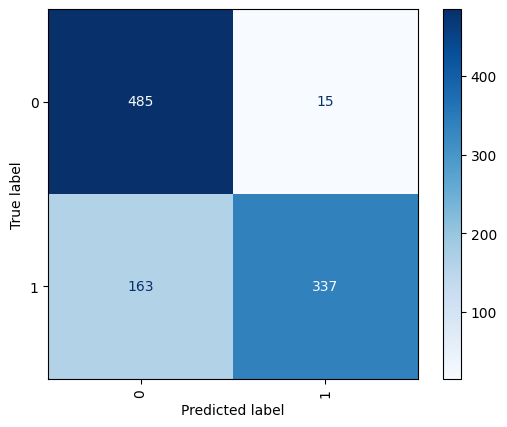

In [63]:
ConfusionMatrixDisplay.from_predictions(y_test, pred, xticks_rotation='vertical', cmap='Blues');

### Valutazione tramite procedura di cross-validation a 5 fold sul training set per selezionare il modello migliore

In [12]:
configs = {
    # 1. ESPERIMENTI SULLE FORME (TOKENS)
    "forme_unigrammi": {
        "colonna": "tokens_processed",
        "analyzer": "word",
        "ngram_range": (1, 1)
    },
    "forme_unigrammi_bigrammi": {
        "colonna": "tokens_processed",
        "analyzer": "word",
        "ngram_range": (1, 2)
    },
    
    # 2. ESPERIMENTI SUI LEMMI
    "lemmi_unigrammi": {
        "colonna": "lemmas_processed",
        "analyzer": "word",
        "ngram_range": (1, 1)
    },
    "lemmi_bigrammi": {
        "colonna": "lemmas_processed",
        "analyzer": "word",
        "ngram_range": (2, 2)
    },
    
    # 3. ESPERIMENTI SULLE PART-OF-SPEECH (SINTASSI)
    "pos_bigrammi": {
        "colonna": "pos_processed",
        "analyzer": "word",
        "ngram_range": (2, 2)
    },
    "pos_trigrammi": {
        "colonna": "pos_processed",
        "analyzer": "word",
        "ngram_range": (3, 3)
    },
    
    # 4. ESPERIMENTI SUI CARATTERI
    # Nota: per i caratteri usiamo la colonna del testo originale 'text'
    "caratteri_3_5_grammi": {
        "colonna": "text",
        "analyzer": "char",
        "ngram_range": (3, 5)
    }
}

In [14]:
for nome_test, params in configs.items():

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer=params["analyzer"],
            ngram_range=params["ngram_range"]
        )),
        ("clf", LinearSVC())
    ])

    scores = cross_val_score(
        pipeline,
        df_train[params["colonna"]],
        y_train,
        cv=5,
        scoring="f1_macro"
    )

    print("\nEsecuzione:", nome_test)
    print("Scores fold:", scores)
    print("Media:", np.mean(scores))


Esecuzione: forme_unigrammi
Scores fold: [0.969988   0.97248607 0.97249158 0.98749805 0.97249983]
Media: 0.9749927033020546

Esecuzione: forme_unigrammi_bigrammi
Scores fold: [0.95996397 0.9774886  0.96998124 0.98499662 0.97249158]
Media: 0.9729844018471552

Esecuzione: lemmi_unigrammi
Scores fold: [0.96246035 0.96748354 0.96498599 0.98249464 0.95498199]
Media: 0.9664813026925627

Esecuzione: lemmi_bigrammi
Scores fold: [0.95492788 0.96246035 0.96247162 0.96999325 0.95997498]
Media: 0.9619656170733745

Esecuzione: pos_bigrammi
Scores fold: [0.93247932 0.919998   0.92249952 0.92249952 0.91749948]
Media: 0.9229951674716041

Esecuzione: pos_trigrammi
Scores fold: [0.94249101 0.94997999 0.92248789 0.94499862 0.93      ]
Media: 0.9379915039832019

Esecuzione: caratteri_3_5_grammi
Scores fold: [0.9799955  0.98749805 0.98249989 0.9874993  0.9874993 ]
Media: 0.9849984059704517


### Valutazione prestazioni del modello scelto attraverso la 5 fold cross-validation sui set di validazione e di test

In [ ]:
"""# 4. ESPERIMENTI SUI CARATTERI
    # Nota: per i caratteri usiamo la colonna del testo originale 'text'
    "caratteri_3_5_grammi": {
        "colonna": "text",
        "analyzer": "char",
        "ngram_range": (3, 5)
    }"""

'# 4. ESPERIMENTI SUI CARATTERI\n    # Nota: per i caratteri usiamo la colonna del testo originale \'text\'\n    "caratteri_3_5_grammi": {\n        "colonna": "text",\n        "analyzer": "char",\n        "ngram_range": (3, 5)\n    }'

### Fix 1 — Task 1: vectorizer addestrato correttamente su train, poi applicato a val/test

In [15]:
best_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=(3, 5))),
    ("clf", LinearSVC())
])

# training finale
best_pipeline.fit(df_train['text'], df_train['label'])

# validation
pred_val = best_pipeline.predict(df_val['text'])

# test
pred_test = best_pipeline.predict(df_test['text'])

print("=== Validation ===")
print(classification_report(df_val['label'], pred_val, zero_division=0))

print("=== Test ===")
print(classification_report(df_test['label'], pred_test, zero_division=0))

=== Validation ===
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       500
           1       0.98      0.97      0.98       500

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000

=== Test ===
              precision    recall  f1-score   support

           0       0.76      0.98      0.85       500
           1       0.98      0.68      0.80       500

    accuracy                           0.83      1000
   macro avg       0.87      0.83      0.83      1000
weighted avg       0.87      0.83      0.83      1000



## 2. Classificatore basato su Support Vector Machine (SVM) lineari e informazioni linguistiche non lessicali.

In [71]:
# --- PER IL TRAIN ---
df_features_train = pd.read_csv('../data/processed/data_task2/train_UD.csv', delimiter='\t')
# 1. Estrai l'ID
df_features_train['doc_id'] = df_features_train['Filename'].str.extract(r'(\d+)').astype(int)
# 2. ORDINA per doc_id per garantire il perfetto allineamento con df_train originale
df_features_train = df_features_train.sort_values(by='doc_id').set_index('doc_id')
# 3. Isola X (rimuovendo anche Filename)
X_train_ud = df_features_train.drop(columns=['Filename'])
y_train_ud = df_train['label'].copy()

/tmp/ipykernel_32332/1967343043.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_features_train['doc_id'] = df_features_train['Filename'].str.extract(r'(\d+)').astype(int)


In [72]:
# --- PER IL TEST ---

profiling_test_path='../data/processed/data_task2/test_UD.csv'
df_features_test = pd.read_csv(profiling_test_path, delimiter='\t')
# 1. Estrai l'ID
df_features_test['doc_id'] = df_features_test['Filename'].str.extract(r'(\d+)').astype(int)
# 2. ORDINA per doc_id per allinearlo a df_test originale
df_features_test = df_features_test.sort_values(by='doc_id').set_index('doc_id')
# 3. Isola X
X_test_ud = df_features_test.drop(columns=['Filename'])
y_test_ud = df_test['label'].copy()

/tmp/ipykernel_32332/1832154943.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_features_test['doc_id'] = df_features_test['Filename'].str.extract(r'(\d+)').astype(int)


In [73]:
"""Cosa sta succedendo (Il problema)
Se leggi attentamente l'errore:
    Nel Training set, Profiling-UD ha estratto una colonna chiamata verbs_num_pers_dist_+.
    Nel Test set, la stessa identica colonna è stata estratta con il nome verbs_num_pers_dist_+3.
Perché succede? Profiling-UD rileva le feature in base ai testi che analizza. 
Se nel training set non c'erano verbi alla terza persona che rispecchiavano quella codifica esatta (o viceversa), lo strumento tronca o modifica leggermente il nome della colonna nel CSV. StandardScaler si accorge che i nomi e l'ordine delle 141 colonne non corrispondono al millimetro tra Train e Test e blocca tutto per sicurezza."""
# Forza il test set ad avere le stesse identiche colonne (e ordine) del train set
X_test_ud = X_test_ud.reindex(columns=X_train_ud.columns, fill_value=0)

### Fix 2 — Task 2: aggiungere valutazione esplicita sul validation set

In [126]:
# Carica le feature di Profiling-UD per il VALIDATION set
df_features_val = pd.read_csv('../data/processed/data_task2/validation.csv', delimiter='\t')
df_features_val['doc_id'] = df_features_val['Filename'].str.extract(r'(\d+)').astype(int)
df_features_val = df_features_val.sort_values(by='doc_id').set_index('doc_id')
X_val_ud = df_features_val.drop(columns=['Filename'])

# Allinea le colonne al training set (stesso fix già usato per il test)
X_val_ud = X_val_ud.reindex(columns=X_train_ud.columns, fill_value=0)
y_val_ud = df_val['label'].copy()

# Predici e stampa i risultati sul validation set
pred_val_ud = model_ud.predict(X_val_ud)

print("=== Validation set (Profiling-UD) ===")
print(classification_report(y_val_ud, pred_val_ud, zero_division=0))

# La valutazione sul test set che hai già rimane invariata
print("=== Test set (Profiling-UD) ===")
print(classification_report(y_test_ud, pred, zero_division=0))

=== Validation set (Profiling-UD) ===
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       500
           1       0.95      0.95      0.95       500

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000

=== Test set (Profiling-UD) ===
              precision    recall  f1-score   support

           0       0.85      0.92      0.88       500
           1       0.92      0.83      0.87       500

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



/tmp/ipykernel_32332/624967815.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_features_val['doc_id'] = df_features_val['Filename'].str.extract(r'(\d+)').astype(int)


In [74]:
model_ud = Pipeline([
    ("scaler", StandardScaler()),  # Scala i numeri di Profiling-UD
    ("clf", LinearSVC())           # Classificatore SVM
])

# Addestramento
model_ud.fit(X_train_ud, y_train_ud)

# Predizione
pred = model_ud.predict(X_test_ud)

# Stampa i risultati corretti
print(classification_report(y_test_ud, pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.85      0.92      0.88       500
           1       0.92      0.83      0.87       500

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



In [75]:
# 1. Ottieni le distanze dal confine della SVM
distanze = model_ud.decision_function(X_test_ud)

# 2. Crea un DataFrame per l'analisi dell'incertezza
df_incertezza = pd.DataFrame({
    'distanza_assoluta': np.abs(distanze),
    'distanza_reale': distanze,
    'testo': df_test['text'],
    'label_reale': y_test_ud,
    'predizione': pred  # le predizioni che hai già calcolato prima
})

# 3. Ordina in base alla distanza più vicina a zero e prendi i primi 5
i_5_più_incerti = df_incertezza.sort_values(by='distanza_assoluta').head(5)

# 4. Visualizza il risultato
display(i_5_più_incerti[['distanza_reale', 'label_reale', 'predizione', 'testo']])

,distanza_reale,label_reale,predizione,testo
815,-0.003327,1,0,Le previsioni meteo degli ultimi giorni preann...
823,0.004401,1,1,L’obiettivo? Ridefinire i equilibri tra esecut...
108,0.010565,0,1,Il confine con la Colombia è il teatro dei mag...
194,-0.012522,1,0,"Una storia iniziata tra mille polemiche, tra c..."
276,0.014760,1,1,L'appuntamento è dunque fissato per il prossim...


In [76]:
print(i_5_più_incerti)

     distanza_assoluta  distanza_reale  \
815           0.003327       -0.003327   
823           0.004401        0.004401   
108           0.010565        0.010565   
194           0.012522       -0.012522   
276           0.014760        0.014760   

                                                 testo  label_reale  \
815  Le previsioni meteo degli ultimi giorni preann...            1   
823  L’obiettivo? Ridefinire i equilibri tra esecut...            1   
108  Il confine con la Colombia è il teatro dei mag...            0   
194  Una storia iniziata tra mille polemiche, tra c...            1   
276  L'appuntamento è dunque fissato per il prossim...            1   

     predizione  
815           0  
823           1  
108           1  
194           0  
276           1  


### 20 features più importanti

In [77]:
# Recuperiamo i pesi assegnati dalla SVM alle colonne di Profiling-UD
pesi = model_ud['clf'].coef_[0]

df_feature_importanti = pd.DataFrame({
    'Feature': X_train_ud.columns,
    'Peso': pesi,
    'Peso_Assoluto': np.abs(pesi)
})

# Prendi le 20 più significative
le_20_dominanti = df_feature_importanti.sort_values(by='Peso_Assoluto', ascending=False).head(20)
print(le_20_dominanti[['Feature', 'Peso']])

                         Feature      Peso
1                       n_tokens -2.419553
93               dep_dist_advmod  1.874903
10                 upos_dist_ADV -1.525584
25               lexical_density -1.457214
80        n_prepositional_chains  1.309277
7            ttr_form_chunks_200 -1.297201
105                 dep_dist_det -1.232503
16                 upos_dist_NUM -1.121213
20               upos_dist_PUNCT  1.016801
18                upos_dist_PRON -0.999782
13                 upos_dist_DET  0.930042
115        dep_dist_flat:foreign -0.893910
98                 dep_dist_case -0.800125
23                upos_dist_VERB -0.775194
79   avg_prepositional_chain_len -0.763023
135    avg_subordinate_chain_len -0.715276
9                  upos_dist_ADP  0.606542
19               upos_dist_PROPN -0.587581
91            dep_dist_acl:relcl  0.542539
120               dep_dist_nsubj  0.501054


## Task 3 - Classificatore basato su SVM lineari e word embedding

In [78]:
import sqlite3

In [79]:
sql_path = f'../data/word_embeddings/itwac128.sqlite'
txt_path = f'../data/word_embeddings/itwac128.txt'

con = sqlite3.connect(sql_path)

cur = con.cursor()

In [80]:
"""legge righe da una tabella SQLite (store) e le salva in un file .txt,
una riga per embedding."""

with open(txt_path, 'w+') as out_file:
    for embedding in cur.execute("SELECT * FROM store"):
        # Prende tutti gli elementi della riga tranne l’ultimo
        # e li converte in stringhe
        str_embedding = [str(el) for el in embedding[:-1]] 
        out_file.write('\t'.join(str_embedding)+'\n')

out_file.close()

In [81]:
def load_word_embeddings(path):
    embeddings = {}
    with open(txt_path, 'r') as f:
        for testo in f:
            line = testo.strip().split('\t')
            word = line[0]
            embedding = line[1:]
            embedding = [float(comp) for comp in embedding] # convertiamo le componenti dell'embedding in float
            embeddings[word] = np.asarray(embedding) # trasformiamo la lista delle componenti in un vettore di numpy
        return embeddings

In [91]:
embeddings = load_word_embeddings(txt_path)
print(f'Numero di parole nel vocabolario: {len(embeddings):,}')
print(f'Dimensione di ogni embedding: {128}')

Numero di parole nel vocabolario: 1,247,492
Dimensione di ogni embedding: 128


Per ogni testo in df_train, prendo i token dalla colonna 'tokens', per ogni token estraggo l'embedding. Faccio la media degli embedding per ogni doc.
Alla fine ottengo una nuova colonna 'vector' contenente un unico vettore per doc

In [129]:
def docs_to_embeddings(docs, embeddings):
    doc_to_array = []

    emb_dim = len(next(iter(embeddings.values())))

    for text in docs:
        vectors = []

        for token in text:
            if token in embeddings:
                vectors.append(embeddings[token])

        if len(vectors) > 0:
            mean_vector = np.mean(vectors, axis=0)
        else:
            mean_vector = np.zeros(emb_dim)

        doc_to_array.append(mean_vector)

    return doc_to_array

df_train['tokens_vector'] = docs_to_embeddings(df_train['tokens'],embeddings)
df_val['tokens_vector'] = docs_to_embeddings(df_val['tokens'],embeddings)
df_test['tokens_vector'] = docs_to_embeddings(df_test['tokens'],embeddings)

df_train['lemmas_vector'] = docs_to_embeddings(df_train['lemmas'],embeddings)
df_val['lemmas_vector'] = docs_to_embeddings(df_val['lemmas'],embeddings)
df_test['lemmas_vector'] = docs_to_embeddings(df_test['lemmas'],embeddings)

In [130]:
X_train_vec = np.vstack(df_train['tokens_vector'].values)
X_val_vec = np.vstack(df_val['tokens_vector'].values)

y_train_vec = df_train['label'].values
y_val_vec = df_val['label'].values

In [131]:
model_vec = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC())
])
model_vec.fit(X_train_vec, y_train_vec)

pred_vec = model_vec.predict(X_val_vec)

# classification report
print(classification_report(y_val_vec, pred_vec, zero_division=0))#, output_dict=True))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94       500
           1       0.94      0.93      0.94       500

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



In [132]:
X_train_vec = np.vstack(df_train['lemmas_vector'].values)
X_val_vec = np.vstack(df_val['lemmas_vector'].values)

y_train_vec = df_train['label'].values
y_val_vec = df_val['label'].values

model_vec = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC())
])
model_vec.fit(X_train_vec, y_train_vec)

pred_vec = model_vec.predict(X_val_vec)

# classification report
print(classification_report(y_val_vec, pred_vec, zero_division=0))#, output_dict=True))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93       500
           1       0.94      0.91      0.92       500

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



In [133]:
type(df_train['tokens'][0])

list

In [134]:
def docs_to_embeddings_pos(docs_tokens, docs_pos, embeddings):
    doc_to_array = []
    emb_dim = len(next(iter(embeddings.values())))

    # Usiamo zip() per scorrere contemporaneamente i testi e le loro etichette POS
    for text_tokens, text_pos in zip(docs_tokens, docs_pos):
        vectors = []
        
        # Se nel tuo dataframe sono salvati come stringhe uniche separate da spazi, 
        # le trasformiamo in liste. Se sono già liste, questo passaggio è innocuo.
        lista_token = text_tokens if isinstance(text_tokens, list) else str(text_tokens).split()
        lista_pos = text_pos if isinstance(text_pos, list) else str(text_pos).split()

        # Ora scorriamo la singola parola appaiata alla sua etichetta grammaticale
        for token, pos_tag in zip(lista_token, lista_pos):
            
            # Controlliamo l'etichetta! In Universal Dependencies le etichette sono:
            # 'NOUN' (nomi comuni), 'PROPN' (nomi propri), 'VERB' (verbi)
            if pos_tag in ['NOUN', 'PROPN', 'VERB']:
                
                # Se passa il filtro grammaticale, cerchiamo il vettore
                if token in embeddings:
                    vectors.append(embeddings[token])

        # Calcolo della media come facevi prima
        if len(vectors) > 0:
            mean_vector = np.mean(vectors, axis=0)
        else:
            mean_vector = np.zeros(emb_dim)

        doc_to_array.append(mean_vector)

    return doc_to_array

In [135]:
df_train['vector_pos'] = docs_to_embeddings_pos(df_train['tokens'], df_train['pos'],embeddings)
df_val['vector_pos'] = docs_to_embeddings_pos(df_val['tokens'], df_val['pos'],embeddings)
df_test['vector_pos'] = docs_to_embeddings_pos(df_test['tokens'], df_test['pos'],embeddings)

In [136]:
X_train_pos = np.vstack(df_train['vector_pos'].values)
X_val_pos = np.vstack(df_val['vector_pos'].values)

y_train_pos = df_train['label'].values
y_val_pos = df_val['label'].values

model_pos = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC())
])
model_pos.fit(X_train_pos, y_train_pos)

pred_pos = model_pos.predict(X_val_pos)

# classification report
print(classification_report(y_val_vec, pred_vec, zero_division=0))#, output_dict=True))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93       500
           1       0.94      0.91      0.92       500

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000

